In [1]:
import requests
import pandas as pd
from io import StringIO
from requests.auth import HTTPBasicAuth

# El '0' indica "mi usuario actual"
url = "https://intervals.icu/api/v1/athlete/0/athlete-summary"

# Reemplaza con tu clave real obtenida en /settings
api_key = "1347lyp9p4meza7lyd3sar4qu" 

# La autenticación usa 'API_KEY' como usuario y tu clave como contraseña
auth = HTTPBasicAuth('API_KEY', api_key)

response = requests.get(url, auth=auth)

if response.status_code == 200:
    atletas = response.json()
      # Imprime la respuesta completa para depuración
    # Quitar duplicados por athlete_id y nombre
    atletas = list({(a.get('athlete_id'), a.get('athlete_name')): a for a in atletas}.values())

   

    meta_burgos = pd.read_csv('data/burgos.csv', sep=';')
    meta_burgos['intervals_id'] = meta_burgos['intervals_id'].astype(str)
    nombres_burgos = dict(zip(meta_burgos['intervals_id'], meta_burgos['Name']))

    for atleta in atletas:
        athlete_id = str(atleta.get('athlete_id'))
        atleta['athlete_name'] = nombres_burgos.get(athlete_id, atleta.get('athlete_name'))

    # Filtrar solo atletas con carrera=1 en burgos.csv
    ids_carrera = set(meta_burgos.loc[meta_burgos['carrera'] == 1, 'intervals_id'].astype(str))
    atletas = [a for a in atletas if str(a.get('athlete_id')) in ids_carrera]

    print(f"Se encontraron {len(atletas)} atletas únicos.")
    print(atletas)
else:
    print(f"Error: {response.status_code}")


Se encontraron 5 atletas únicos.
[{'count': 0, 'time': 0, 'moving_time': 0, 'elapsed_time': 0, 'calories': 0, 'total_elevation_gain': 0.0, 'training_load': 0, 'srpe': 0, 'distance': 0.0, 'eftp': None, 'eftpPerKg': None, 'date': '2026-08-24', 'athlete_id': 'i547904', 'athlete_name': 'Jose Luis Faura', 'email': None, 'external_id': None, 'fitness': 22.05309, 'fatigue': 32.054005, 'form': -10.000916, 'rampRate': 3.7226639, 'weight': None, 'timeInZones': [0, 0, 0, 0, 0, 0, 0, 0], 'timeInZonesTot': 0, 'byCategory': [{'count': 0, 'time': 0, 'moving_time': 0, 'elapsed_time': 0, 'calories': 0, 'total_elevation_gain': 0.0, 'training_load': 0, 'srpe': 0, 'distance': 0.0, 'eftp': 343.4778, 'eftpPerKg': None, 'category': 'Ride'}], 'mostRecentWellnessId': '2026-08-24'}, {'count': 0, 'time': 0, 'moving_time': 0, 'elapsed_time': 0, 'calories': 0, 'total_elevation_gain': 0.0, 'training_load': 0, 'srpe': 0, 'distance': 0.0, 'eftp': None, 'eftpPerKg': None, 'date': '2026-08-24', 'athlete_id': 'i547157',

In [2]:
print("\n=== NOMBRES DE ATLETAS ===")
for atleta in atletas:
    print(f"- {atleta['athlete_name']} - id {atleta['athlete_id']}")


=== NOMBRES DE ATLETAS ===
- Jose Luis Faura - id i547904
- Jose Manuel Diaz - id i547157
- Cesar Macias - id i281806
- Mario Aparicio - id i554068
- Sinuhe Fernandez - id i545516


== NOMBRES DE ATLETAS ===
- Adrian Fajardo - id i547906
- Alex Mayer - id i93850
- CarlosGarcia11 - id i495562
- Eric Fagundez - id i553889
- Georgios Bouglas - id i554492
- Jose Luis Faura - id i547904
- Josemanueldiaz - id i547157
- LorenzoQ - id i545517
- Maciaspetro - id i281806
- Martin Rey - id i554086
- Sinuhé - id i545516
- Vojtěch Kmínek - id i554486
- oka_ander - id i546414
- Mario Aparicio - id i554068


In [3]:
from datetime import datetime, timedelta
 
print("\n=== ESTADÍSTICAS DE ENTRENAMIENTO ===")
for i, atleta in enumerate(atletas, 1):
    nombre = atleta['athlete_name']
    fecha = atleta['date']
    distancia_m = atleta['distance']  # en metros
    distancia_km = distancia_m / 1000  # convertir a km
    tiempo_s = atleta['moving_time']  # en segundos
    calorias = atleta.get('calories', 0)
    kilojulios = calorias * 4.184  # 1 kcal = 4.184 kJ
    peso = atleta.get('weight')
    print(f"\n{i}. {nombre} - Fecha: {fecha}")
    # Convertir tiempo a hh:mm:ss
    horas = tiempo_s // 3600
    minutos = (tiempo_s % 3600) // 60
    segundos = tiempo_s % 60
    tiempo_formateado = f"{int(horas):02d}:{int(minutos):02d}:{int(segundos):02d}"
    
    # Calcular velocidad media en km/h
    tiempo_h = tiempo_s / 3600
    velocidad_media = distancia_km / tiempo_h if tiempo_h > 0 else 0
    
    # Calcular trabajo/peso (en kJ/kg)
    trabajo_por_peso = kilojulios / peso if peso and peso > 0 else 65

    print(f"{nombre}, {fecha}, {distancia_km:.2f}km, {trabajo_por_peso:.2f}kj/kg")
    
    # Configurar rango de fechas (últimos 90 días)
    oldest = (datetime.now() - timedelta(days=3)).strftime('%Y-%m-%d')
    newest = datetime.now().strftime('%Y-%m-%d')

    url_actividades = f"https://intervals.icu/api/v1/athlete/{atleta['athlete_id']}/activities?oldest={oldest}&newest={newest}"
    url = f"https://intervals.icu/api/v1/athlete/{atleta['athlete_id']}/activities.csv"

    # 3. Parámetros de fecha (obligatorios para listar actividades)
    parametros = {
        "oldest": "2024-01-01",
        "newest": "2024-04-20"
    }


    response_actividades = requests.get(url_actividades, auth=auth)
    print()
    if response_actividades.status_code == 200:
        actividades = response_actividades.json()
        print(f"\n=== ACTIVIDADES DEL ATLETA ===")
        print(f"Se encontraron {len(actividades)} actividades.\n")
    
        for i, actividad in enumerate(actividades, 1):
            fuente = actividad.get('source', 'No se encontró la fuente de datos')
            print(fuente)
            fecha = actividad.get('start_date_local', 'N/A')
            nombre = actividad.get('name', 'Sin nombre')
            tipo_deporte = actividad.get('type', 'N/A')
            distancia = (actividad.get('distance') or 0) / 1000  # convertir a km
            tiempo = actividad.get('moving_time') or 0
            id_actividad = actividad.get('id')
                        
            
            if fuente == 'STRAVA':
                url = f"https://intervals.icu/api/v1/activity/{id_actividad}/streams"

                

                # 3. Petición GET
                response = requests.get(url, auth=auth)
                print(f"Solicitando streams en JSON para la actividad {id_actividad}...{response.status_code}")

                if response.status_code == 200:
                    # 4. Convertir la respuesta directamente a un diccionario/lista JSON
                    datos_streams = response.json()
                    print("¡Éxito! Datos de telemetría descargados.")
                    
                    # Inspeccionar la estructura recibida para ver qué métricas están disponibles
                    # Generalmente devuelve una lista de objetos donde cada uno es un flujo (ej: 'watts', 'heartrate')
                    if isinstance(datos_streams, list):
                        print("\nFlujos de datos disponibles en esta actividad:")
                        for stream in datos_streams:
                            tipo_flujo = stream.get("type", "Desconocido")
                            cantidad_puntos = len(stream.get("data", []))
                            print(f"- {tipo_flujo}: {cantidad_puntos} puntos de datos")
                            
                else:
                    print(f"Error {response.status_code}: No se pudo descargar la información.")
           
            # Convertir tiempo a hh:mm:ss
            horas_a = tiempo // 3600
            minutos_a = (tiempo % 3600) // 60
            segundos_a = tiempo % 60
            tiempo_formateado_a = f"{int(horas_a):02d}:{int(minutos_a):02d}:{int(segundos_a):02d}"
                    
            # Calcular velocidad o ritmo según el tipo de deporte
            if tipo_deporte == 'Run' and distancia > 0:
                # Para Run: calcular ritmo en min/km
                minutos_por_km = tiempo / 60 / distancia
                min_ritmo = int(minutos_por_km)
                seg_ritmo = int((minutos_por_km - min_ritmo) * 60)
                ritmo_str = f"{min_ritmo}:{seg_ritmo:02d} min/km"
                velocidad_str = ritmo_str
            else:
                # Para otros deportes: velocidad en km/h
                tiempo_h_a = tiempo / 3600
                velocidad = (distancia / tiempo_h_a) if tiempo_h_a > 0 else 0
                velocidad_str = f"{velocidad:.2f} km/h"
        
            print(f"{i}. {fecha} - {nombre} ({tipo_deporte})")
            print(f"   Distancia: {distancia:.2f} km | Tiempo: {tiempo_formateado_a} | Ritmo/Velocidad: {velocidad_str}")
        
            if not id_actividad:
                print("   Actividad sin id, se omiten detalles y curva de potencia.")
                print()
                continue

            # Obtener detalles completos de la actividad para interval_summary
            url_detalle = f"https://intervals.icu/api/v1/athlete/{atleta['athlete_id']}/activities/{id_actividad}"
            response_detalle = requests.get(url_detalle, auth=auth)
            
            if response_detalle.status_code == 200:
                detalle_act = response_detalle.json()
                if isinstance(detalle_act, list) and len(detalle_act) > 0:
                    detalle_act = detalle_act[0]
                
                # Mostrar interval_summary si existe
                if 'interval_summary' in detalle_act and detalle_act['interval_summary']:
                    print(f"   Intervalos: {', '.join(detalle_act['interval_summary'])}")
            
            url_power = f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv"
            response_power = requests.get(url_power, auth=auth)

            if response_power.status_code == 422:
                print("   Curva de potencia no disponible vía API para esta actividad.")
                print()
                continue

            if response_power.status_code != 200:
                print(f"   Error al obtener power-curve: {response_power.status_code}")
                print()
                continue

            # Parsear CSV de power-curve y extraer 300s, 600s, 1200s
            try:
                df_curve = pd.read_csv(StringIO(response_power.text))
            except Exception as e:
                print(f"   No se pudo parsear power-curve.csv: {e}")
                print()
                continue

            cols = {c.lower(): c for c in df_curve.columns}
            sec_col = next((cols[c] for c in cols if 'sec' in c), None)
            watts_col = next((cols[c] for c in cols if 'watt' in c or c == 'w'), None)

            if sec_col is None or watts_col is None:
                print(f"   Columnas no detectadas en CSV. Columnas: {list(df_curve.columns)}")
                print()
                continue

            df_curve[sec_col] = pd.to_numeric(df_curve[sec_col], errors='coerce')
            df_curve[watts_col] = pd.to_numeric(df_curve[watts_col], errors='coerce')
            df_curve = df_curve.dropna(subset=[sec_col, watts_col])

            objetivos = [30,120,300, 600, 1200]
            mejores = {}

            for s in objetivos:
                fila = df_curve[df_curve[sec_col] == s]
                if not fila.empty:
                    mejores[s] = float(fila[watts_col].max())
                else:
                    mejores[s] = None

            print(
                "   Mejores potencias -> "
                f"30s: {f'{mejores[30]:.0f}W' if mejores[30] is not None else 'N/D'} | "
                f"2': {f'{mejores[120]:.0f}W' if mejores[120] is not None else 'N/D'} | "
                f"5': {f'{mejores[300]:.0f}W' if mejores[300] is not None else 'N/D'} | "
                f"10': {f'{mejores[600]:.0f}W' if mejores[600] is not None else 'N/D'} | "
                f"20': {f'{mejores[1200]:.0f}W' if mejores[1200] is not None else 'N/D'}"
            )
            print()
    else:
        print(f"Error al obtener actividades: {response_actividades.status_code}")
        print(response_actividades.text)
    
    if response.status_code == 200:
            datos_bienestar = response.json()
            print(response.json())
            print(f"\n=== DATOS DE BIENESTAR DEL ATLETA ===")
            print(f"Se obtuvieron datos de {len(datos_bienestar)} días.{oldest} - {newest}")
            # Procesar la lista de objetos devuelta
            for dia in datos_bienestar:
                print(dia)
                # El campo 'id' siempre contiene la fecha del registro
                fecha = dia.get('id')
                peso = dia.get('weight', 'Sin dato')
                pasos = dia.get('steps', 'Sin dato')
                hrv_rmssd = dia.get('hrv', 'Sin dato') 
                hrv_sdnn = dia.get('hrvSDNN', 'Sin dato')  
                
                print(f"Fecha: {fecha} - Peso: {peso}kg - Pasos: {pasos} - HRV RMSSD: {hrv_rmssd} - HRV SDNN: {hrv_sdnn}")
    else:
            print(f"Error: {response.status_code}")



=== ESTADÍSTICAS DE ENTRENAMIENTO ===

1. Jose Luis Faura - Fecha: 2026-08-24
Jose Luis Faura, 2026-08-24, 0.00km, 65.00kj/kg


=== ACTIVIDADES DEL ATLETA ===
Se encontraron 4 actividades.

WAHOO
1. 2026-08-23T11:39:48 - Ciclismo (Ride)
   Distancia: 224.78 km | Tiempo: 05:44:15 | Ritmo/Velocidad: 39.18 km/h
   Intervalos: 1x 5m26s 297w, 1x 3m59s 322w, 2x 12s 591w, 1x 23s 618w
   Mejores potencias -> 30s: 576W | 2': 389W | 5': 368W | 10': 314W | 20': 285W

WAHOO
2. 2026-08-22T18:37:45 - Ciclismo (Ride)
   Distancia: 9.21 km | Tiempo: 00:10:56 | Ritmo/Velocidad: 50.56 km/h
   Intervalos: 1x 98s 404w
   Mejores potencias -> 30s: 496W | 2': 405W | 5': 345W | 10': 311W | 20': N/D

WAHOO
3. 2026-08-22T17:49:59 - WU (Ride)
   Distancia: 0.00 km | Tiempo: 00:27:17 | Ritmo/Velocidad: 0.00 km/h
   Mejores potencias -> 30s: 374W | 2': 334W | 5': 270W | 10': 240W | 20': 212W

WAHOO
4. 2026-08-22T13:19:18 - Ciclismo (Ride)
   Distancia: 40.20 km | Tiempo: 01:01:48 | Ritmo/Velocidad: 39.03 km/h
  

In [4]:
from datetime import datetime, timedelta
from io import StringIO
import pandas as pd
import requests

# 1. Configuración de atleta y fechas
athlete_id = "i554068"  # Mario Aparicio (o el atleta deseado / variable)
dias_atras = 30           # Rango de días para actividades recientes

oldest = (datetime.now() - timedelta(days=dias_atras)).strftime('%Y-%m-%d')
newest = datetime.now().strftime('%Y-%m-%d')

duraciones = [5, 30, 60, 300, 600, 1200]
dur_cols = ['5s (W)', '30s (W)', '1m (W)', '5m (W)', '10m (W)', '20m (W)']
dur_map = dict(zip(duraciones, dur_cols))

# 2. Obtener récord histórico absoluto del ciclista
url_hist = f"https://intervals.icu/api/v1/athlete/{athlete_id}/power-curves"
r_hist = requests.get(url_hist, auth=auth, params={'curves': 'all', 'type': 'Ride'})

sec_to_watt_hist = {}
sec_to_wkg_hist = {}

if r_hist.status_code == 200:
    r_hist.encoding = 'utf-8-sig'
    data_hist = r_hist.json()
    if data_hist.get('list'):
        curva_hist = data_hist['list'][0]
        sec_to_watt_hist = dict(zip(curva_hist.get('secs', []), curva_hist.get('watts', [])))
        sec_to_wkg_hist = dict(zip(curva_hist.get('secs', []), curva_hist.get('watts_per_kg', [])))
else:
    print(f"Aviso: No se pudo obtener curva histórica ({r_hist.status_code})")

# 3. Obtener actividades recientes y sus curvas de potencia
url_actividades = f"https://intervals.icu/api/v1/athlete/{athlete_id}/activities?oldest={oldest}&newest={newest}"
response_actividades = requests.get(url_actividades, auth=auth)

filas = []

if response_actividades.status_code == 200:
    actividades = response_actividades.json()
    print(f"Se encontraron {len(actividades)} actividades para el atleta {athlete_id}.")

    for actividad in actividades:
        if actividad.get('source') == 'STRAVA':
            continue

        fecha = actividad.get('start_date_local', 'N/A')[:10]
        nombre = actividad.get('name', 'Sin nombre')
        distancia = (actividad.get('distance') or 0) / 1000
        tiempo = actividad.get('moving_time') or 0

        horas = tiempo // 3600
        minutos = (tiempo % 3600) // 60
        segundos = tiempo % 60
        tiempo_str = f"{int(horas):02d}:{int(minutos):02d}:{int(segundos):02d}"

        fila = {
            'Fecha': fecha,
            'Actividad': nombre,
            'Dist (km)': round(distancia, 1),
            'Tiempo': tiempo_str
        }

        # Descargar y parsear power-curve de la actividad
        id_actividad = actividad.get('id')
        if id_actividad:
            url_detalle = f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv"
            response_detalle = requests.get(url_detalle, auth=auth)

            if response_detalle.status_code == 200:
                try:
                    df_curve = pd.read_csv(StringIO(response_detalle.text))
                    cols = {c.lower(): c for c in df_curve.columns}
                    sec_col = next((cols[c] for c in cols if 'sec' in c), None)
                    watts_col = next((cols[c] for c in cols if 'watt' in c or c == 'w'), None)

                    if sec_col and watts_col:
                        df_curve[sec_col] = pd.to_numeric(df_curve[sec_col], errors='coerce')
                        df_curve[watts_col] = pd.to_numeric(df_curve[watts_col], errors='coerce')
                        df_curve = df_curve.dropna(subset=[sec_col, watts_col])

                        for s in duraciones:
                            sub = df_curve[df_curve[sec_col] == s]
                            fila[dur_map[s]] = round(float(sub[watts_col].max()), 0) if not sub.empty else None
                except Exception:
                    pass

        # Rellenar None si no hubo datos para esa duración
        for s in duraciones:
            if dur_map[s] not in fila:
                fila[dur_map[s]] = None

        filas.append(fila)

else:
    print(f"Error al obtener actividades: {response_actividades.status_code}")
    print(response_actividades.text)

# 4. Añadir las filas de RÉCORD HISTÓRICO a la matriz
if sec_to_watt_hist:
    # Fila de vatios históricos
    fila_rec_w = {
        'Fecha': 'HISTÓRICO',
        'Actividad': '★ RÉCORD ABSOLUTO (W)',
        'Dist (km)': '-',
        'Tiempo': '-'
    }
    for s in duraciones:
        val = sec_to_watt_hist.get(s)
        fila_rec_w[dur_map[s]] = round(float(val), 0) if val is not None else None
    filas.append(fila_rec_w)

    # Fila de W/kg históricos
    fila_rec_wkg = {
        'Fecha': 'HISTÓRICO',
        'Actividad': '★ RÉCORD ABSOLUTO (W/kg)',
        'Dist (km)': '-',
        'Tiempo': '-'
    }
    for s in duraciones:
        val = sec_to_wkg_hist.get(s)
        fila_rec_wkg[dur_map[s]] = f"{float(val):.2f} W/kg" if val is not None else None
    filas.append(fila_rec_wkg)

# 5. Construir y mostrar el DataFrame / Matriz de resultados
df_matriz = pd.DataFrame(filas)

print("\n=== MATRIZ DE POTENCIAS CON RÉCORDS HISTÓRICOS ===")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(df_matriz)


Se encontraron 31 actividades para el atleta i554068.

=== MATRIZ DE POTENCIAS CON RÉCORDS HISTÓRICOS ===


,Fecha,Actividad,Dist (km),Tiempo,5s (W),30s (W),1m (W),5m (W),10m (W),20m (W)
0,2026-08-23,Lunch Ciclismo,224.7,05:43:06,918.0,674.0,516.0,423.0,399.0,321.0
1,2026-08-22,Afternoon Ciclismo virtual,0.0,00:10:01,229.0,190.0,169.0,132.0,116.0,None
2,2026-08-22,Afternoon Ciclismo,9.1,00:11:03,848.0,621.0,549.0,384.0,374.0,None
3,2026-08-22,Afternoon Ciclismo virtual,14.0,00:25:44,843.0,479.0,470.0,348.0,268.0,229.0
4,2026-08-22,Lunch Ciclismo,30.1,00:47:59,567.0,410.0,366.0,268.0,249.0,232.0
5,2026-08-21,Lunch Ciclismo,51.7,01:35:54,672.0,511.0,494.0,473.0,441.0,336.0
6,2026-08-20,Lunch Ciclismo virtual,39.8,01:00:59,401.0,313.0,292.0,234.0,197.0,186.0
7,2026-08-19,Morning Ciclismo,70.1,02:17:50,559.0,346.0,297.0,280.0,258.0,252.0
8,2026-08-18,Morning Ciclismo,103.3,03:00:26,572.0,502.0,489.0,434.0,390.0,372.0
9,2026-08-16,Lunch Ciclismo,40.9,01:22:15,386.0,320.0,285.0,216.0,208.0,181.0


In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from requests.auth import HTTPBasicAuth

# Requiere que existan api_key y atletas (de la celda 1)
if 'api_key' not in globals():
    raise ValueError("No existe api_key. Ejecuta primero la celda 1.")

if 'atletas' not in globals() or not atletas:
    raise ValueError("No existe la lista de atletas. Ejecuta primero la celda 1.")

auth = HTTPBasicAuth('API_KEY', api_key)


def _a_int_segundos(valor):
    """Convierte duraciones a segundos: 300, '300s', '5m', etc."""
    if valor is None:
        return None

    if isinstance(valor, (int, float)):
        v = int(float(valor))
        return v if v > 0 else None

    if isinstance(valor, str):
        t = valor.strip().lower()
        if t.endswith('s') and t[:-1].replace('.', '', 1).isdigit():
            return int(float(t[:-1]))
        if t.endswith('m') and t[:-1].replace('.', '', 1).isdigit():
            return int(float(t[:-1]) * 60)
        if t.endswith('min') and t[:-3].replace('.', '', 1).isdigit():
            return int(float(t[:-3]) * 60)
        if t.replace('.', '', 1).isdigit():
            return int(float(t))

    return None


def _es_curva_plana_no_util(mejores):
    """Detecta respuestas típicas de relleno (p. ej. todo 100 W)."""
    if not mejores:
        return True
    valores = [round(float(v), 3) for v in mejores.values() if v is not None]
    if not valores:
        return True
    return len(set(valores)) == 1 and valores[0] in (100.0, 0.0)


def extraer_mejores_por_periodo(datos):
    """Devuelve {segundos: mejor_watts} recorriendo estructuras JSON anidadas."""
    mejores = {}

    def actualizar(segundos, watts):
        s = _a_int_segundos(segundos)
        if s is None or s <= 0:
            return
        try:
            w = float(watts)
        except (TypeError, ValueError):
            return
        if w <= 0:
            return
        if s not in mejores or w > mejores[s]:
            mejores[s] = w

    def recorrer(obj):
        if isinstance(obj, list):
            for item in obj:
                recorrer(item)
            return

        if not isinstance(obj, dict):
            return

        # Caso común: item con campos de periodo y potencia
        posibles_periodos = [
            obj.get('secs'), obj.get('seconds'), obj.get('duration'),
            obj.get('duration_s'), obj.get('period'), obj.get('time')
        ]
        posibles_watts = [
            obj.get('watts'), obj.get('power'), obj.get('w'),
            obj.get('value'), obj.get('best')
        ]

        for p in posibles_periodos:
            for w in posibles_watts:
                if p is not None and w is not None:
                    actualizar(p, w)

        # Caso: dict tipo {'300': 420, '600': 360}
        for k, v in obj.items():
            ks = _a_int_segundos(k)
            if ks is not None and isinstance(v, (int, float, str)):
                actualizar(ks, v)

            # Seguir recorriendo contenido anidado
            if isinstance(v, (dict, list)):
                recorrer(v)

    recorrer(datos)
    return mejores


def _extraer_desde_csv_actividades(athlete_id, max_acts=30):
    """Fallback: usa power-curve.csv por actividad cuando power-curves no da datos parseables."""
    mejores = {}

    url_acts = f"https://intervals.icu/api/v1/athlete/{athlete_id}/activities"
    params = {'oldest': '2023-01-01', 'newest': '2026-12-31'}
    r = requests.get(url_acts, auth=auth, params=params, timeout=25)
    if r.status_code != 200:
        return mejores

    acts = r.json() if isinstance(r.json(), list) else []

    for act in acts[:max_acts]:
        id_actividad = act.get('id')
        if not id_actividad:
            continue

        url_power = f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv"
        rp = requests.get(url_power, auth=auth, timeout=25)
        if rp.status_code != 200:
            continue

        try:
            df = pd.read_csv(StringIO(rp.text))
        except Exception:
            continue

        cols = {c.lower(): c for c in df.columns}
        sec_col = next((cols[c] for c in cols if 'sec' in c), None)
        watts_col = next((cols[c] for c in cols if 'watt' in c or c == 'w'), None)
        if sec_col is None or watts_col is None:
            continue

        df[sec_col] = pd.to_numeric(df[sec_col], errors='coerce')
        df[watts_col] = pd.to_numeric(df[watts_col], errors='coerce')
        df = df.dropna(subset=[sec_col, watts_col])

        for _, row in df.iterrows():
            s = _a_int_segundos(row[sec_col])
            if s is None or s <= 0:
                continue
            w = float(row[watts_col])
            if w <= 0:
                continue
            if s not in mejores or w > mejores[s]:
                mejores[s] = w

    return mejores


print("Descargando curvas de potencia para todos los atletas...")
registros = []
atletas_sin_datos = []

for atleta in atletas:
    athlete_id = str(atleta.get('athlete_id'))
    athlete_name = atleta.get('athlete_name', athlete_id)

    url = f"https://intervals.icu/api/v1/athlete/{athlete_id}/power-curves"
    parametros = {
        "type": "Ride",
        "includeRanks": "true",
        "curves": "r.2023-01-01.2026-12-31"
    }

    try:
        response = requests.get(url, auth=auth, params=parametros, timeout=25)
    except requests.RequestException as e:
        print(f"\n{athlete_name} ({athlete_id})")
        print(f"  Error de conexión: {e}")
        atletas_sin_datos.append(athlete_name)
        continue

    if response.status_code != 200:
        print(f"\n{athlete_name} ({athlete_id})")
        print(f"  Error HTTP {response.status_code}: {response.text}")
        atletas_sin_datos.append(athlete_name)
        continue

    datos_curvas = response.json()
    mejores_por_periodo = extraer_mejores_por_periodo(datos_curvas)

    # Fallback al CSV por actividad si el JSON no trae pares periodo/potencia detectables
    # o si devuelve una curva plana no realista (normalmente datos de relleno).
    if _es_curva_plana_no_util(mejores_por_periodo):
        mejores_por_periodo = _extraer_desde_csv_actividades(athlete_id, max_acts=30)

    print(f"\n=== {athlete_name} ({athlete_id}) ===")

    if not mejores_por_periodo:
        print("No se pudieron extraer periodos/potencias para este atleta.")
        atletas_sin_datos.append(athlete_name)
        continue

    for secs in sorted(mejores_por_periodo):
        watts = mejores_por_periodo[secs]
        etiqueta = f"{secs // 60}m {secs % 60}s" if secs >= 60 and secs % 60 != 0 else (f"{secs // 60}m" if secs >= 60 else f"{secs}s")
        print(f"Periodo {etiqueta:>6} ({secs:>4}s): {watts:.0f} W")
        registros.append(
            {
                'athlete_id': athlete_id,
                'athlete_name': athlete_name,
                'period_s': secs,
                'period_label': etiqueta,
                'best_watts': round(float(watts), 1),
            }
        )

# DataFrame final con todos los atletas y periodos
mejores_df = pd.DataFrame(registros)

if mejores_df.empty:
    print("\nNo se pudieron construir datos de mejores potencias con la información disponible.")
    if atletas_sin_datos:
        print("Atletas sin datos detectables:", ', '.join(sorted(set(atletas_sin_datos))))
    print("Sugerencia: revisar permisos API de potencia o ampliar el rango de fechas/actividades.")
else:
    mejores_df = mejores_df.sort_values(['period_s', 'athlete_name']).reset_index(drop=True)
    print("\n=== DataFrame consolidado: mejores_df ===")
    print(mejores_df.head(20))

    # Gráfico comparativo por periodo y atleta
    pivot_mejores = mejores_df.pivot_table(
        index='period_label',
        columns='athlete_name',
        values='best_watts',
        aggfunc='max'
    )

    orden_periodos = (
        mejores_df[['period_label', 'period_s']]
        .drop_duplicates()
        .sort_values('period_s')['period_label']
        .tolist()
    )
    pivot_mejores = pivot_mejores.reindex(orden_periodos)

    ax = pivot_mejores.plot(kind='bar', figsize=(15, 7), width=0.85)
    ax.set_title('Mejor potencia por periodo (todos los atletas)')
    ax.set_xlabel('Periodo')
    ax.set_ylabel('Potencia (W)')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Atleta', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

mejores_df

Descargando curvas de potencia para todos los atletas...

=== Jose Luis Faura (i547904) ===
No se pudieron extraer periodos/potencias para este atleta.

=== Jose Manuel Diaz (i547157) ===
No se pudieron extraer periodos/potencias para este atleta.

=== Cesar Macias (i281806) ===
No se pudieron extraer periodos/potencias para este atleta.

=== Mario Aparicio (i554068) ===
No se pudieron extraer periodos/potencias para este atleta.

=== Sinuhe Fernandez (i545516) ===
No se pudieron extraer periodos/potencias para este atleta.

No se pudieron construir datos de mejores potencias con la información disponible.
Atletas sin datos detectables: Cesar Macias, Jose Luis Faura, Jose Manuel Diaz, Mario Aparicio, Sinuhe Fernandez
Sugerencia: revisar permisos API de potencia o ampliar el rango de fechas/actividades.


""


calculo ctl,atl y ramp

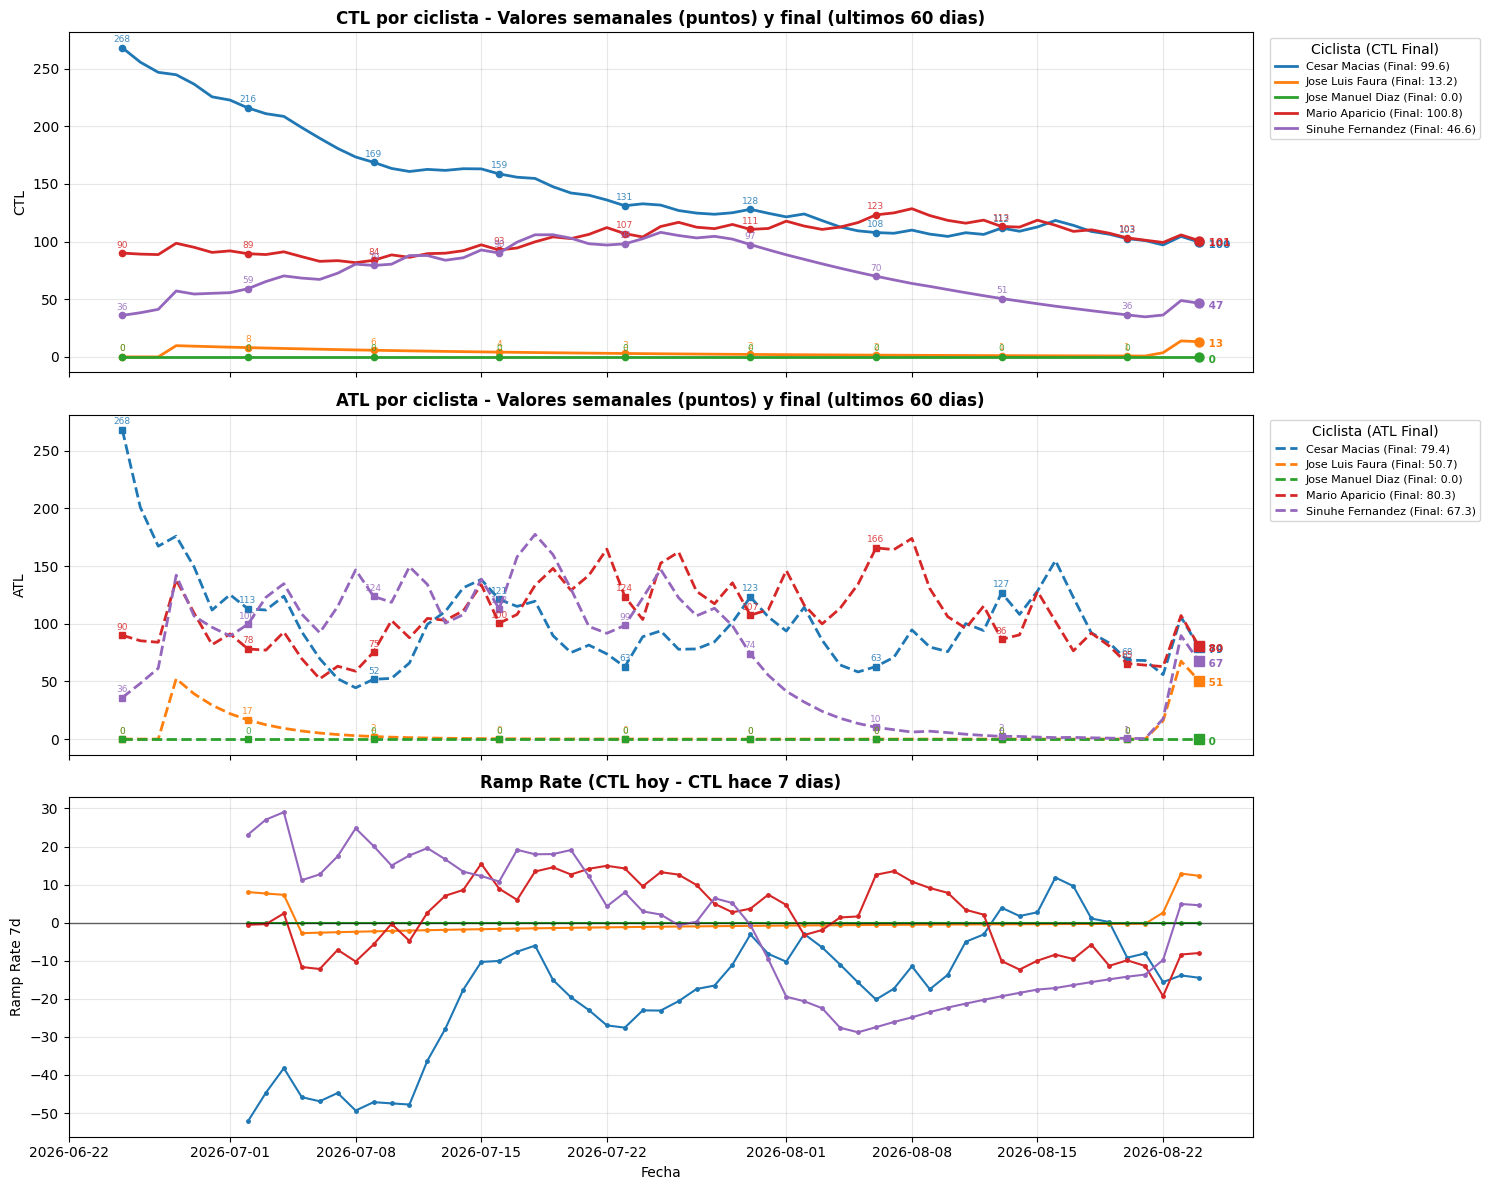


=== Resumen de valores de CTL y ATL (Semanales y Final) ===


,athlete_name,fecha,tipo,ctl,atl,ramp_rate_7d
0,Cesar Macias,2026-06-25,Semanal,268.0,268.0,NaN
1,Cesar Macias,2026-07-02,Semanal,215.8,112.9,-52.16
2,Cesar Macias,2026-07-09,Semanal,168.7,51.8,-47.15
3,Cesar Macias,2026-07-16,Semanal,158.6,121.1,-10.06
4,Cesar Macias,2026-07-23,Semanal,131.1,62.7,-27.58
5,Cesar Macias,2026-07-30,Semanal,128.0,123.2,-3.10
6,Cesar Macias,2026-08-06,Semanal,107.8,62.9,-20.18
7,Cesar Macias,2026-08-13,Semanal,111.7,126.8,3.93
8,Cesar Macias,2026-08-20,Semanal,102.5,68.5,-9.20
9,Cesar Macias,2026-08-24,FINAL,99.6,79.4,-14.46


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Requiere que existan api_key y atletas (de celdas anteriores)
if 'api_key' not in globals():
    raise ValueError("No existe api_key. Ejecuta primero la celda de autenticacion.")

if 'atletas' not in globals() or not atletas:
    raise ValueError("No existe la lista de atletas. Ejecuta primero la celda que carga athlete-summary.")

auth = HTTPBasicAuth('API_KEY', api_key)
meta_burgos = pd.read_csv('data/burgos.csv', sep=';')
meta_burgos['intervals_id'] = meta_burgos['intervals_id'].astype(str)
nombres_burgos = dict(zip(meta_burgos['intervals_id'], meta_burgos['Name']))

# Para calcular bien CTL/ATL en ultimos x dias, tomamos una ventana de carga mas larga
hoy = datetime.now().date()
fecha_inicio_plot = hoy - timedelta(days=60)
fecha_inicio_carga = hoy - timedelta(days=60)

fechas_completas = pd.date_range(start=fecha_inicio_carga, end=hoy, freq='D')
resultado = []

for atleta in atletas:
    athlete_id = str(atleta.get('athlete_id'))
    nombre_api = atleta.get('athlete_name', f"athlete_{athlete_id}")
    nombre = nombres_burgos.get(athlete_id, nombre_api)

    url_acts = (
        f"https://intervals.icu/api/v1/athlete/{athlete_id}/activities"
        f"?oldest={fecha_inicio_carga}&newest={hoy}"
    )
    r = requests.get(url_acts, auth=auth)

    if r.status_code != 200:
        print(f"No se pudieron cargar actividades de {nombre} (status {r.status_code})")
        continue

    json_data = r.json()
    acts = json_data if isinstance(json_data, list) else []
    if not acts:
        continue

    rows = []
    for act in acts:
        fecha_txt = act.get('start_date_local') or act.get('start_date')
        if not fecha_txt:
            continue

        fecha = pd.to_datetime(fecha_txt, errors='coerce')
        if pd.isna(fecha):
            continue

        load = act.get('icu_training_load')
        if load is None:
            load = act.get('training_load')
        if load is None:
            load = 0

        rows.append({"fecha": fecha.date(), "load": float(load)})

    if not rows:
        continue

    df = pd.DataFrame(rows)
    df_diario = (
        df.groupby('fecha', as_index=False)['load']
        .sum()
        .rename(columns={'load': 'daily_load'})
    )

    serie = pd.DataFrame({'fecha': fechas_completas.date})
    serie = serie.merge(df_diario, on='fecha', how='left')
    serie['daily_load'] = serie['daily_load'].fillna(0.0)

    # CTL y ATL con medias exponenciales clasicas
    serie['ctl'] = serie['daily_load'].ewm(span=42, adjust=False).mean()
    serie['atl'] = serie['daily_load'].ewm(span=7, adjust=False).mean()

    # Ramp Rate diario: cambio de CTL respecto a hace 7 dias
    serie['ramp_rate_7d'] = serie['ctl'] - serie['ctl'].shift(7)

    serie['athlete_name'] = nombre
    serie_30 = serie[serie['fecha'] >= fecha_inicio_plot].copy()
    resultado.append(serie_30)

if not resultado:
    raise ValueError("No se encontraron datos para calcular CTL/ATL/Ramp Rate.")

metrics_df = pd.concat(resultado, ignore_index=True)
metrics_df['fecha'] = pd.to_datetime(metrics_df['fecha'])

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Mantener colores consistentes por ciclista en los 3 paneles
nombres = sorted(metrics_df['athlete_name'].unique())
palette = plt.cm.tab20.colors if len(nombres) > 10 else plt.cm.tab10.colors
color_map = {nombre: palette[i % len(palette)] for i, nombre in enumerate(nombres)}

# Panel 1: CTL con valores semanales y final
for nombre, g in metrics_df.groupby('athlete_name'):
    g_sorted = g.sort_values('fecha').reset_index(drop=True)
    g_sem = g_sorted.iloc[::7].copy()
    last_row = g_sorted.iloc[-1]
    final_ctl = last_row['ctl']

    # Curva y marcadores semanales
    axes[0].plot(g_sorted['fecha'], g_sorted['ctl'], linewidth=2, color=color_map[nombre], label=f"{nombre} (Final: {final_ctl:.1f})")
    axes[0].plot(g_sem['fecha'], g_sem['ctl'], marker='o', markersize=4.5, linestyle='', color=color_map[nombre])
    axes[0].plot(last_row['fecha'], final_ctl, marker='o', markersize=6.5, color=color_map[nombre])

    # Valor final anotado al extremo de la linea
    axes[0].annotate(f" {final_ctl:.0f}", (last_row['fecha'], final_ctl),
                     textcoords="offset points", xytext=(4, -2), fontsize=7.5, fontweight='bold',
                     color=color_map[nombre], va='center')

    # Valores semanales sobre los puntos
    for _, row in g_sem.iterrows():
        axes[0].annotate(f"{row['ctl']:.0f}", (row['fecha'], row['ctl']),
                         textcoords="offset points", xytext=(0, 4), fontsize=6.5,
                         color=color_map[nombre], ha='center', alpha=0.85)

axes[0].set_title('CTL por ciclista - Valores semanales (puntos) y final (ultimos 60 dias)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('CTL')          
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Ciclista (CTL Final)', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Panel 2: ATL con valores semanales y final
for nombre, g in metrics_df.groupby('athlete_name'):
    g_sorted = g.sort_values('fecha').reset_index(drop=True)
    g_sem = g_sorted.iloc[::7].copy()
    last_row = g_sorted.iloc[-1]
    final_atl = last_row['atl']

    # Curva y marcadores semanales
    axes[1].plot(g_sorted['fecha'], g_sorted['atl'], linewidth=2, linestyle='--', color=color_map[nombre], label=f"{nombre} (Final: {final_atl:.1f})")
    axes[1].plot(g_sem['fecha'], g_sem['atl'], marker='s', markersize=4.5, linestyle='', color=color_map[nombre])
    axes[1].plot(last_row['fecha'], final_atl, marker='s', markersize=6.5, color=color_map[nombre])

    # Valor final anotado al extremo de la linea
    axes[1].annotate(f" {final_atl:.0f}", (last_row['fecha'], final_atl),
                     textcoords="offset points", xytext=(4, -2), fontsize=7.5, fontweight='bold',
                     color=color_map[nombre], va='center')

    # Valores semanales sobre los puntos
    for _, row in g_sem.iterrows():
        axes[1].annotate(f"{row['atl']:.0f}", (row['fecha'], row['atl']),
                         textcoords="offset points", xytext=(0, 4), fontsize=6.5,
                         color=color_map[nombre], ha='center', alpha=0.85)

axes[1].set_title('ATL por ciclista - Valores semanales (puntos) y final (ultimos 60 dias)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ATL')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Ciclista (ATL Final)', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Panel 3: Ramp Rate
for nombre, g in metrics_df.groupby('athlete_name'):
    axes[2].plot(g['fecha'], g['ramp_rate_7d'], marker='o', markersize=2.5, linewidth=1.5, color=color_map[nombre])

axes[2].axhline(0, color='black', linewidth=1, alpha=0.6)
axes[2].set_title('Ramp Rate (CTL hoy - CTL hace 7 dias)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Ramp Rate 7d')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen en tabla de valores semanales y final
resumen_semanal = []
for nombre, g in metrics_df.groupby('athlete_name'):
    g_sorted = g.sort_values('fecha').reset_index(drop=True)
    g_sem = g_sorted.iloc[::7].copy()
    last_row = g_sorted.iloc[-1]
    for _, r in g_sem.iterrows():
        resumen_semanal.append({
            'athlete_name': nombre,
            'fecha': r['fecha'].strftime('%Y-%m-%d'),
            'tipo': 'Semanal',
            'ctl': round(r['ctl'], 1),
            'atl': round(r['atl'], 1),
            'ramp_rate_7d': round(r['ramp_rate_7d'], 2) if pd.notnull(r['ramp_rate_7d']) else None
        })
    resumen_semanal.append({
        'athlete_name': nombre,
        'fecha': last_row['fecha'].strftime('%Y-%m-%d'),
        'tipo': 'FINAL',
        'ctl': round(last_row['ctl'], 1),
        'atl': round(last_row['atl'], 1),
        'ramp_rate_7d': round(last_row['ramp_rate_7d'], 2) if pd.notnull(last_row['ramp_rate_7d']) else None
    })

resumen_df = pd.DataFrame(resumen_semanal).drop_duplicates(subset=['athlete_name', 'fecha'])
print("\n=== Resumen de valores de CTL y ATL (Semanales y Final) ===")
resumen_df.sort_values(['athlete_name', 'fecha']).reset_index(drop=True)

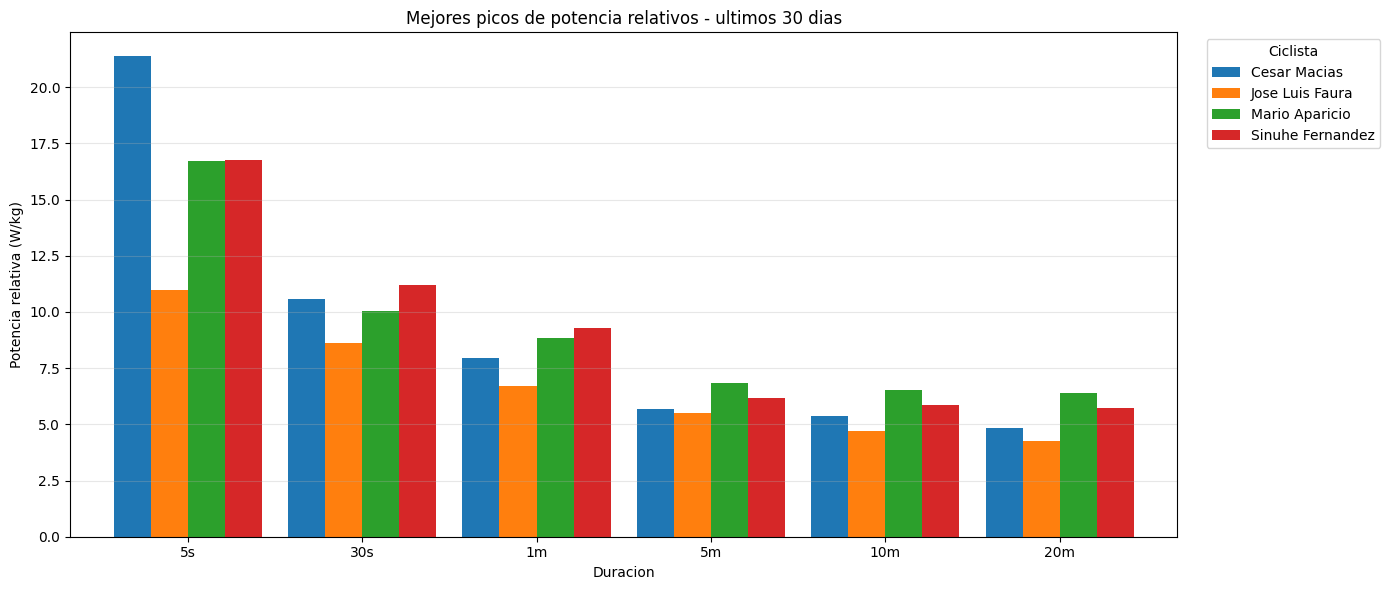

,athlete_id,athlete_name,weight_kg,duration_s,duration_label,peak_watts,peak_wkg,peak_date,all_time_watts,all_time_wkg,all_time_date
0,i281806,Cesar Macias,57,5,5s,1218,21.37,2026-08-21,1237,21.70,2024-01-28
1,i281806,Cesar Macias,57,30,30s,602,10.56,2026-08-23,738,12.95,2025-03-02
2,i281806,Cesar Macias,57,60,1m,454,7.96,2026-08-23,596,10.46,2024-12-21
3,i281806,Cesar Macias,57,300,5m,323,5.67,2026-08-23,389,6.82,2026-04-27
4,i281806,Cesar Macias,57,600,10m,307,5.39,2026-08-22,348,6.11,2025-04-18
5,i281806,Cesar Macias,57,1200,20m,275,4.82,2026-08-16,329,5.77,2025-01-07
6,i547904,Jose Luis Faura,67,5,5s,736,10.99,2026-08-23,1046,15.61,2026-03-20
7,i547904,Jose Luis Faura,67,30,30s,576,8.60,2026-08-23,686,10.24,2026-03-24
8,i547904,Jose Luis Faura,67,60,1m,448,6.69,2026-08-23,623,9.30,2026-05-03
9,i547904,Jose Luis Faura,67,300,5m,368,5.49,2026-08-23,449,6.70,2026-04-03


In [7]:
from datetime import datetime, timedelta
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt
import requests

if 'auth' not in globals() or 'atletas' not in globals():
    raise ValueError("Ejecuta primero la celda 2 para cargar autenticacion y atletas.")

oldest_30 = (datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')
newest_30 = datetime.now().strftime('%Y-%m-%d')

meta_burgos = pd.read_csv('data/burgos.csv', sep=';')
meta_burgos['intervals_id'] = meta_burgos['intervals_id'].astype(str)
meta_burgos['weight'] = pd.to_numeric(meta_burgos['weight'], errors='coerce')
meta_burgos = meta_burgos.rename(columns={'Name': 'display_name', 'weight': 'weight_kg'})
meta_burgos = meta_burgos[['intervals_id', 'display_name', 'weight_kg']]

duraciones = [5, 30, 60, 300, 600, 1200]
labels_duracion = {5: '5s', 30: '30s', 60: '1m', 300: '5m', 600: '10m', 1200: '20m'}


def leer_curva(response):
    try:
        curva = pd.read_csv(StringIO(response.text))
    except Exception:
        return None, None, None
    cols = {c.lower(): c for c in curva.columns}
    sec_col = next((cols[c] for c in cols if 'sec' in c), None)
    watts_col = next((cols[c] for c in cols if 'watt' in c or c == 'w'), None)
    if sec_col is None or watts_col is None:
        return None, None, None
    curva[sec_col] = pd.to_numeric(curva[sec_col], errors='coerce')
    curva[watts_col] = pd.to_numeric(curva[watts_col], errors='coerce')
    return curva.dropna(subset=[sec_col, watts_col]), sec_col, watts_col


def obtener_records_historicos(athlete_id):
    """Obtiene el record historico y la fecha de la actividad que lo produjo."""
    records = {d: {'watts': None, 'date': None} for d in duraciones}
    url = f"https://intervals.icu/api/v1/athlete/{athlete_id}/power-curves"

    try:
        response = requests.get(
            url, auth=auth, params={'curves': 'all', 'type': 'Ride'}, timeout=25
        )
    except requests.RequestException:
        return records

    if response.status_code != 200:
        return records

    data = response.json()
    curvas = data.get('list', []) if isinstance(data, dict) else []
    if isinstance(curvas, dict):
        curvas = [curvas]
    for curva in curvas:
        if not isinstance(curva, dict):
            continue
        for segundos, valor in zip(curva.get('secs', []), curva.get('watts', [])):
            try:
                duracion = int(float(segundos))
                potencia = float(valor)
            except (TypeError, ValueError):
                continue
            if duracion in records and potencia > 0:
                if records[duracion]['watts'] is None or potencia > records[duracion]['watts']:
                    records[duracion]['watts'] = potencia

    # El endpoint de curvas devuelve una fecha agregada; localizar la actividad real.
    url_actividades = f"https://intervals.icu/api/v1/athlete/{athlete_id}/activities"
    params = {'oldest': '1980-01-01', 'newest': newest_30}
    try:
        response_actividades = requests.get(url_actividades, auth=auth, params=params, timeout=25)
    except requests.RequestException:
        return records
    if response_actividades.status_code != 200:
        return records

    actividades = response_actividades.json()
    actividades = actividades if isinstance(actividades, list) else []
    for actividad in actividades:
        if all(records[d]['date'] is not None for d in duraciones if records[d]['watts'] is not None):
            break
        id_actividad = actividad.get('id')
        if not id_actividad:
            continue
        try:
            response_power = requests.get(
                f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv",
                auth=auth, timeout=25
            )
        except requests.RequestException:
            continue
        if response_power.status_code != 200:
            continue
        curva, sec_col, watts_col = leer_curva(response_power)
        if curva is None:
            continue
        fecha = (actividad.get('start_date_local') or actividad.get('start_date') or '')[:10]
        for duracion in duraciones:
            record = records[duracion]
            if record['watts'] is None or record['date'] is not None:
                continue
            fila = curva[curva[sec_col] == duracion]
            if not fila.empty and fila[watts_col].max() >= record['watts'] - 0.5:
                record['date'] = fecha

    return records


resultados = []
max_actividades_por_atleta = 20

for atleta in atletas:
    athlete_id = str(atleta.get('athlete_id'))
    athlete_name = atleta.get('athlete_name', athlete_id)
    meta_row = meta_burgos[meta_burgos['intervals_id'] == athlete_id]
    if meta_row.empty:
        print(f"No se encontró {athlete_name} en burgos.csv")
        continue

    display_name = meta_row.iloc[0]['display_name']
    weight_kg = meta_row.iloc[0]['weight_kg']
    if pd.isna(weight_kg) or weight_kg <= 0:
        print(f"Peso no válido para {display_name} en burgos.csv")
        continue

    records_historicos = obtener_records_historicos(athlete_id)
    url_actividades = (
        f"https://intervals.icu/api/v1/athlete/{athlete_id}/activities"
        f"?oldest={oldest_30}&newest={newest_30}"
    )
    try:
        r = requests.get(url_actividades, auth=auth, timeout=25)
    except requests.RequestException:
        print(f"No se pudieron leer actividades de {display_name}")
        continue
    if r.status_code != 200:
        print(f"No se pudieron leer actividades de {display_name} ({r.status_code})")
        continue

    json_acts = r.json()
    actividades_30 = json_acts if isinstance(json_acts, list) else []
    if not actividades_30:
        continue

    mejores_atleta = {d: None for d in duraciones}
    mejores_atleta_fecha = {d: None for d in duraciones}
    for act in actividades_30[:max_actividades_por_atleta]:
        id_actividad = act.get('id')
        if not id_actividad:
            continue
        act_fecha = (act.get('start_date_local') or act.get('start_date') or '')[:10]
        try:
            r_power = requests.get(
                f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv",
                auth=auth, timeout=25
            )
        except requests.RequestException:
            continue
        if r_power.status_code != 200:
            continue
        df_curve, sec_col, watts_col = leer_curva(r_power)
        if df_curve is None:
            continue
        for d in duraciones:
            fila = df_curve[df_curve[sec_col] == d]
            if fila.empty:
                continue
            val = float(fila[watts_col].max())
            if mejores_atleta[d] is None or val > mejores_atleta[d]:
                mejores_atleta[d] = val
                mejores_atleta_fecha[d] = act_fecha

    for d in duraciones:
        peak_watts = mejores_atleta[d]
        historic_watts = records_historicos[d]['watts']
        resultados.append({
            'athlete_id': athlete_id,
            'athlete_name': display_name,
            'weight_kg': weight_kg,
            'duration_s': d,
            'duration_label': labels_duracion[d],
            'peak_watts': peak_watts,
            'peak_wkg': (peak_watts / weight_kg) if peak_watts is not None else None,
            'peak_date': mejores_atleta_fecha[d],
            'all_time_watts': historic_watts,
            'all_time_wkg': (historic_watts / weight_kg) if historic_watts is not None else None,
            'all_time_date': records_historicos[d]['date'],
        })

peaks_df = pd.DataFrame(resultados)
if peaks_df.empty:
    raise ValueError('No se encontraron picos de potencia en los ultimos 30 dias.')

for columna in ['peak_watts', 'all_time_watts']:
    peaks_df[columna] = pd.array(pd.to_numeric(peaks_df[columna], errors='coerce').round(), dtype='Int64')
for columna in ['peak_wkg', 'all_time_wkg']:
    peaks_df[columna] = pd.to_numeric(peaks_df[columna], errors='coerce').round(2)

plot_df = peaks_df.dropna(subset=['peak_wkg']).copy()
if plot_df.empty:
    raise ValueError('No hay datos validos de potencia para las duraciones objetivo.')

pivot = plot_df.pivot_table(index='duration_label', columns='athlete_name', values='peak_wkg', aggfunc='max').reindex([labels_duracion[d] for d in duraciones])
ax = pivot.plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set_title('Mejores picos de potencia relativos - ultimos 30 dias')
ax.set_xlabel('Duracion')
ax.set_ylabel('Potencia relativa (W/kg)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.legend(title='Ciclista', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

peaks_df.sort_values(['athlete_name', 'duration_s']).reset_index(drop=True)

In [8]:
# Tabla de resultados de la celda 9 en formato matriz
if 'peaks_df' not in globals() or peaks_df.empty:
    raise ValueError("No hay datos de picos. Ejecuta primero la celda 9.")

orden_duraciones = ['5s', '30s', '1m', '5m', '10m', '20m']


def construir_tabla_picos(watts_col, wkg_col, fecha_col):
    tabla_watts = peaks_df.pivot_table(
        index='duration_label', columns='athlete_name', values=watts_col, aggfunc='max'
    ).reindex(orden_duraciones)
    tabla_wkg = peaks_df.pivot_table(
        index='duration_label', columns='athlete_name', values=wkg_col, aggfunc='max'
    ).reindex(orden_duraciones)
    tabla_fecha = (
        peaks_df.dropna(subset=[watts_col])
        .sort_values(watts_col, ascending=False)
        .drop_duplicates(subset=['duration_label', 'athlete_name'])
        .pivot_table(
            index='duration_label', columns='athlete_name', values=fecha_col, aggfunc='first'
        )
        .reindex(orden_duraciones)
    )
    tabla = tabla_watts.copy().astype(object)
    for fila in tabla.index:
        for columna in tabla.columns:
            watts = tabla_watts.loc[fila, columna]
            wkg = tabla_wkg.loc[fila, columna]
            fecha = tabla_fecha.loc[fila, columna] if columna in tabla_fecha.columns else None
            fecha_str = f"\n({fecha})" if fecha and not (isinstance(fecha, float) and pd.isna(fecha)) else ""
            if pd.isna(watts) and pd.isna(wkg):
                tabla.loc[fila, columna] = ''
            elif pd.isna(watts):
                tabla.loc[fila, columna] = f"{wkg:.1f} W/kg{fecha_str}"
            elif pd.isna(wkg):
                tabla.loc[fila, columna] = f"{int(watts)} W{fecha_str}"
            else:
                tabla.loc[fila, columna] = f"{int(watts)} W | {wkg:.1f} W/kg{fecha_str}"
    return tabla


tabla_30_dias = construir_tabla_picos('peak_watts', 'peak_wkg', 'peak_date')
tabla_historica = construir_tabla_picos('all_time_watts', 'all_time_wkg', 'all_time_date')

columnas_juntas = []
for ciclista in tabla_30_dias.columns:
    columnas_juntas.extend([(ciclista, '30 dias'), (ciclista, 'historico')])

columnas_multi = pd.MultiIndex.from_tuples(columnas_juntas)
tabla_peaks = pd.concat(
    [
        tabla_30_dias.rename(columns=lambda ciclista: (ciclista, '30 dias')),
        tabla_historica.rename(columns=lambda ciclista: (ciclista, 'historico')),
    ],
    axis=1,
).reindex(columns=columnas_multi)
tabla_peaks.index.name = 'potencia'

# Colorear únicamente la celda de 30 días según su comparación con el histórico.
colores_tabla = pd.DataFrame('', index=tabla_peaks.index, columns=tabla_peaks.columns)
for ciclista in tabla_30_dias.columns:
    for duracion in orden_duraciones:
        reciente = pd.to_numeric(tabla_30_dias.loc[duracion, ciclista], errors='coerce')
        historico = pd.to_numeric(tabla_historica.loc[duracion, ciclista], errors='coerce')
        if pd.isna(reciente) or pd.isna(historico):
            continue
        columna_reciente = (ciclista, '30 dias')
        if reciente < historico * 0.85:
            colores_tabla.loc[duracion, columna_reciente] = 'background-color: #f8d7da; color: #842029'
        elif reciente >= historico:
            colores_tabla.loc[duracion, columna_reciente] = 'background-color: #d1e7dd; color: #0f5132'

tabla_peaks_styled = tabla_peaks.style.apply(lambda _: colores_tabla, axis=None)
tabla_peaks_styled

PDF CON MEJORES POTENCIAS DE LOS ULTIMOS 30 DIAS,CTL Y ATL

PDF generado en: C:\Users\echav\OneDrive\Documentos\GitHub\procyclingstats\intervals_informe_20260824_155308.pdf


WindowsPath('C:/Users/echav/OneDrive/Documentos/GitHub/procyclingstats/intervals_informe_20260824_155308.pdf')

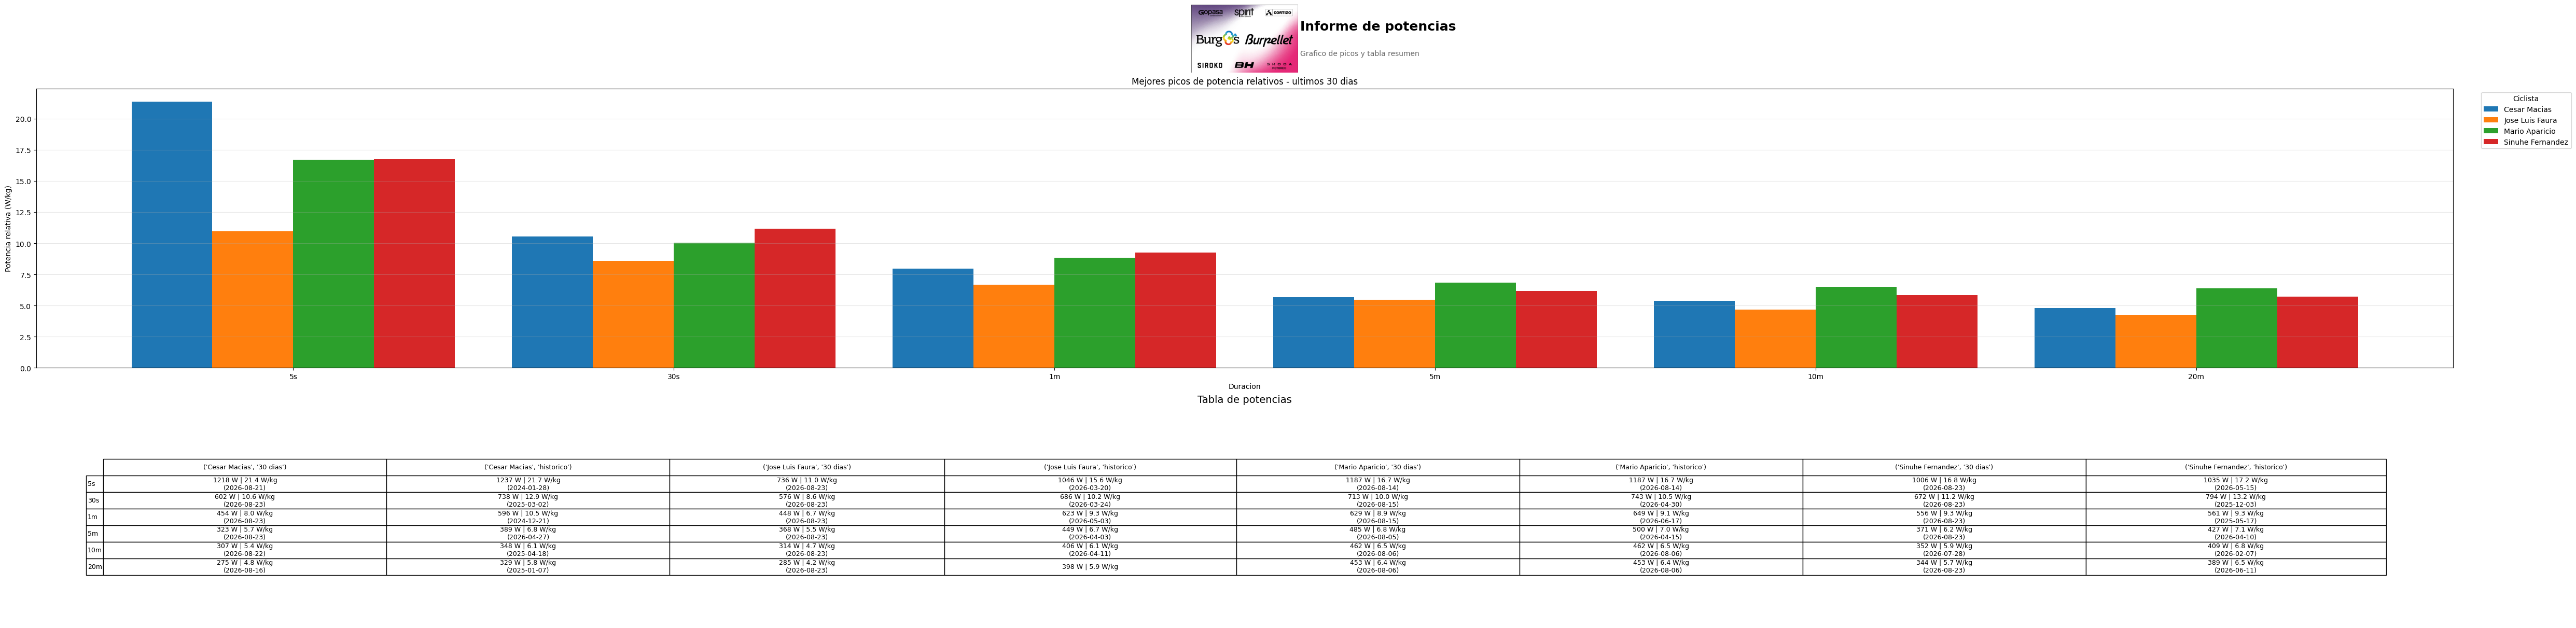

In [9]:
from datetime import datetime
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

if 'plot_df' not in globals() or plot_df.empty:
    raise ValueError("No hay datos del grafico de potencias. Ejecuta primero la celda 9.")

if 'tabla_peaks' not in globals() or tabla_peaks.empty:
    raise ValueError("No hay tabla de potencias. Ejecuta primero la celda 10.")

if 'metrics_df' not in globals() or metrics_df.empty:
    raise ValueError("No hay datos de CTL/ATL. Ejecuta primero la celda 8.")

output_pdf = Path('intervals_informe.pdf')
logo_path = Path('LOGO.png')
orden_duraciones = ['5s', '30s', '1m', '5m', '10m', '20m']

pivot_pdf = plot_df.pivot_table(
    index='duration_label',
    columns='athlete_name',
    values='peak_wkg',
    aggfunc='max'
).reindex(orden_duraciones)

tabla_pdf = tabla_peaks.fillna('').astype(str)
nombres_metricas = sorted(metrics_df['athlete_name'].dropna().unique())
palette = plt.cm.tab20.colors if len(nombres_metricas) > 10 else plt.cm.tab10.colors
color_map_pdf = {
    nombre: palette[i % len(palette)]
    for i, nombre in enumerate(nombres_metricas)
}

logo_img = plt.imread(logo_path) if logo_path.exists() else None


def add_header(ax, titulo, subtitulo):
    ax.axis('off')
    if logo_img is not None:
        ax.imshow(logo_img)
        ax.set_aspect('equal')
    ax.text(
        1.02,
        0.68,
        titulo,
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='center'
    )
    ax.text(
        1.02,
        0.28,
        subtitulo,
        transform=ax.transAxes,
        fontsize=10,
        color='dimgray',
        va='center'
    )


def ajustar_anchos_tabla(table, tabla_df):
    pesos = [max(10, len(str(tabla_df.index.name or 'potencia')) + 2)]
    for columna in tabla_df.columns:
        max_contenido = max(tabla_df[columna].map(len).max(), len(str(columna)))
        pesos.append(max(12, max_contenido + 2))

    ancho_total = 0.98
    escala = ancho_total / sum(pesos)
    anchos = [peso * escala for peso in pesos]

    for fila in range(1, len(tabla_df.index) + 1):
        table[(fila, -1)].set_width(anchos[0])

    for columna in range(len(tabla_df.columns)):
        table[(0, columna)].set_width(anchos[columna + 1])
        for fila in range(1, len(tabla_df.index) + 1):
            table[(fila, columna)].set_width(anchos[columna + 1])


def crear_pagina_potencias(pdf):
    fig_ancho = max(17, 7 + sum(max(12, max(tabla_pdf[col].map(len).max(), len(str(col))) + 2) for col in tabla_pdf.columns) * 0.16)
    fig_alto = max(12, 7 + len(tabla_pdf.index) * 0.55)
    fig_power = plt.figure(figsize=(fig_ancho, fig_alto), constrained_layout=True)
    gs_power = fig_power.add_gridspec(3, 1, height_ratios=[0.8, 3.3, 2.5])

    ax_header_power = fig_power.add_subplot(gs_power[0])
    add_header(ax_header_power, 'Informe de potencias', 'Grafico de picos y tabla resumen')

    ax_plot = fig_power.add_subplot(gs_power[1])
    pivot_pdf.plot(kind='bar', ax=ax_plot, width=0.85)
    ax_plot.set_title('Mejores picos de potencia relativos - ultimos 30 dias')
    ax_plot.set_xlabel('Duracion')
    ax_plot.set_ylabel('Potencia relativa (W/kg)')
    ax_plot.grid(axis='y', alpha=0.3)
    ax_plot.tick_params(axis='x', rotation=0)
    ax_plot.legend(title='Ciclista', bbox_to_anchor=(1.01, 1), loc='upper left')

    ax_table = fig_power.add_subplot(gs_power[2])
    ax_table.axis('off')
    ax_table.set_title('Tabla de potencias', fontsize=14, pad=12)
    table = ax_table.table(
        cellText=tabla_pdf.values,
        rowLabels=tabla_pdf.index.tolist(),
        colLabels=tabla_pdf.columns.tolist(),
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.45)
    ajustar_anchos_tabla(table, tabla_pdf)

    pdf.savefig(fig_power, bbox_inches='tight')
    plt.close(fig_power)


def crear_pagina_carga(pdf):
    fig_load = plt.figure(figsize=(16, 11), constrained_layout=True)
    gs_load = fig_load.add_gridspec(3, 1, height_ratios=[0.8, 2.3, 2.3])

    ax_header_load = fig_load.add_subplot(gs_load[0])
    add_header(ax_header_load, 'Informe de carga', 'CTL y ATL por ciclista (valores semanales y final)')

    ax_ctl = fig_load.add_subplot(gs_load[1])
    for nombre, g in metrics_df.groupby('athlete_name'):
        g_sorted = g.sort_values('fecha').reset_index(drop=True)
        g_sem = g_sorted.iloc[::7].copy()
        last_row = g_sorted.iloc[-1]
        final_ctl = last_row['ctl']

        ax_ctl.plot(g_sorted['fecha'], g_sorted['ctl'], linewidth=2, color=color_map_pdf[nombre], label=f"{nombre} (Final: {final_ctl:.1f})")
        ax_ctl.plot(g_sem['fecha'], g_sem['ctl'], marker='o', markersize=4.5, linestyle='', color=color_map_pdf[nombre])
        ax_ctl.plot(last_row['fecha'], final_ctl, marker='o', markersize=6.5, color=color_map_pdf[nombre])
        ax_ctl.annotate(f" {final_ctl:.0f}", (last_row['fecha'], final_ctl), textcoords="offset points", xytext=(4, -2), fontsize=7.5, fontweight='bold', color=color_map_pdf[nombre], va='center')
        for _, row in g_sem.iterrows():
            ax_ctl.annotate(f"{row['ctl']:.0f}", (row['fecha'], row['ctl']), textcoords="offset points", xytext=(0, 4), fontsize=6.5, color=color_map_pdf[nombre], ha='center', alpha=0.85)

    ax_ctl.set_title('CTL por ciclista - Valores semanales y final')
    ax_ctl.set_ylabel('CTL')
    ax_ctl.grid(True, alpha=0.3)
    ax_ctl.legend(title='Ciclista (CTL Final)', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

    ax_atl = fig_load.add_subplot(gs_load[2], sharex=ax_ctl)
    for nombre, g in metrics_df.groupby('athlete_name'):
        g_sorted = g.sort_values('fecha').reset_index(drop=True)
        g_sem = g_sorted.iloc[::7].copy()
        last_row = g_sorted.iloc[-1]
        final_atl = last_row['atl']

        ax_atl.plot(g_sorted['fecha'], g_sorted['atl'], linewidth=2, linestyle='--', color=color_map_pdf[nombre], label=f"{nombre} (Final: {final_atl:.1f})")
        ax_atl.plot(g_sem['fecha'], g_sem['atl'], marker='s', markersize=4.5, linestyle='', color=color_map_pdf[nombre])
        ax_atl.plot(last_row['fecha'], final_atl, marker='s', markersize=6.5, color=color_map_pdf[nombre])
        ax_atl.annotate(f" {final_atl:.0f}", (last_row['fecha'], final_atl), textcoords="offset points", xytext=(4, -2), fontsize=7.5, fontweight='bold', color=color_map_pdf[nombre], va='center')
        for _, row in g_sem.iterrows():
            ax_atl.annotate(f"{row['atl']:.0f}", (row['fecha'], row['atl']), textcoords="offset points", xytext=(0, 4), fontsize=6.5, color=color_map_pdf[nombre], ha='center', alpha=0.85)

    ax_atl.set_title('ATL por ciclista - Valores semanales y final')
    ax_atl.set_xlabel('Fecha')
    ax_atl.set_ylabel('ATL')
    ax_atl.grid(True, alpha=0.3)
    ax_atl.legend(title='Ciclista (ATL Final)', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

    pdf.savefig(fig_load, bbox_inches='tight')
    plt.close(fig_load)


def crear_informe(pdf):
    crear_pagina_potencias(pdf)
    crear_pagina_carga(pdf)


output_final = output_pdf
try:
    with PdfPages(output_final) as pdf:
        crear_informe(pdf)
except PermissionError:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_final = Path(f'intervals_informe_{timestamp}.pdf')
    with PdfPages(output_final) as pdf:
        crear_informe(pdf)

print(f"PDF generado en: {output_final.resolve()}")
output_final.resolve()